<a href="https://colab.research.google.com/github/cperalta22/rconcolab/blob/master/ejercicioPromotores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reto de programación

En este notebook deberás **completar** el código para llevar a cabo las acciones.

Además de lo anterior inserta celdas de texto donde comentes tu abordaje, sobre todo si es que no te salió.

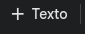


Tambien describe que acciones tomaste para completar la tarea.


## Crea un **tibble** de regiones genómicas

desde el repositorio de la clase descarga y carga como tibble el archivo genes.bed el mismo se encuentra en la carpeta datosTarea2

alternativamente abre la terminal en este notebook

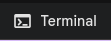

y escribe `wget https://raw.githubusercontent.com/cperalta22/rconcolab/refs/heads/master/datosTarea2/genes.bed`

In [31]:
# Completa el código

# Asegurate de no importar datos como nombres de columnas
# Debe haber 140670 filas y 6 columnas
# Debes usar read_tsv() específicamente
bed <- read_tsv("genes.bed")

Rows: 140669 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (4): 1, ENSMUST00000193812, ., +
dbl (2): 3143476, 3144545

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


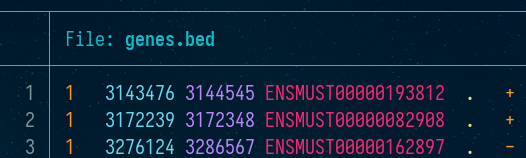

El archivo contiene un **bedfile** de 6 columnas:

| Columna | Descripción | Nuevo nombre |
|---|---|---|
|1 | Identificador de cromosoma | cromo |
|2 | Inicio de la coordenada | ini |
|3 | Fin de la coordenada | fin |
|4 | Nombre del gen | gen |
|5 | Score (no se usa en el ejercicio) | score |
|6 | Hebra del genoma | strand|


Se trata de un archivo con las coordenadas de los genes de un genoma, dependiendo de la hebra del ADN dónde se encuentre en la columna 6 se identifica cómo `+` ó  `-`


In [4]:
# Agrega el nombre correcto a cada columna



glimpse(bed)

## Lógica del ejercicio

1 - Los genes pueden estar ubicados en la hebra (strand) positiva ó negativa del ADN.

2 - Nuestro interés es obtener los promotores de cada uno de los genes de nuestra tabla.

3 - Consideraremos el promotor de un gen como 1000 bases antes del TSS (Las flechitas en la imagen de abajo) y 300 bases después del mismo.

4 - Crearemos las columnas iniProm y finProm para guardar la información.

5 - Ninguna de las dos columnas debe contener números negativos

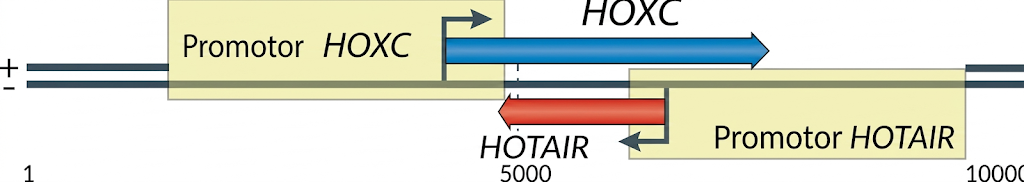

In [15]:
# Creación de las columnas
# Aqui no debes hacer nada tú

bed$iniProm <- c("inicio")
bed$finProm <- c("final")

## Parte 1

Completa el código a continuación considerando lo dicho en la sección "Lógica del ejercicio" de este notebook.

Explica su funcionamiento en una celda de texto ó con comentarios (`#comentario`) dentro del código.

In [20]:
# Primero usaremos la sintaxis de R base

# Revisa y completa el código, ten cuidado con errores de:
# lógica, sintaxis y de ejecución.
# una vez que no tengas errores en tu codigo, este demorará algunos minutos en
# ejecutarse

for( i in 1:nrow(bed)){
  if (bed$strand[i] == "+"){
    if (bed$ini[i] - 1000 >= 1){
      #### COMPLETA ESTA SECCIÓN
    } else {
      bed$finProm[i] <- bed$ini[i] + 300
      bed$iniProm[i] <- 1
    }
  } else if(bed$strand[i] == "-"){
   ### COMPLETA ESTA SECCIÓN
  }
}

In [21]:
# Verifica el resultado

###### NO EJECUTES DE NUEVO ESTA CELDA SI QUIERES COMPARAR CON EL RESULTADO DEL PROFE ######

#head(bed)

cromo,ini,fin,gen,score,strand,iniProm,finProm
<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1,3143476,3144545,ENSMUST00000193812,.,+,3142476,3143776
1,3172239,3172348,ENSMUST00000082908,.,+,3171239,3172539
1,3276124,3286567,ENSMUST00000162897,.,-,3286267,3287567
1,3276746,3285855,ENSMUST00000159265,.,-,3285555,3286855
1,3284705,3741721,ENSMUST00000070533,.,-,3741421,3742721
1,3322980,3323459,ENSMUST00000192857,.,+,3321980,3323280


# Hagamos más eficiente el código usando el `tidyverse` y `pmax()`


En el ejemplo anterior usamos una aproximación iterativa, es decir corrimos mas de 140,000 veces el mismo código, de ahi que fuese tan lenta la ejecución.

Sin embargo tiene la ventaja de ser claro y entendible.

Existen abordajes mas eficientes y aprovechando que R puede manejar vectores y arreglos muy facilmente.

Completa el siguiente código y comenta las diferencias con el anterior.

In [29]:


bed <- bed |>
  mutate(
    # Calculamos el inicio del promotor (TSS aguas arriba o abajo según la hebra)
    # pmax(1, valor) asegura que si el cálculo da un número < 1, se asigne 1.
    iniPromTidy = case_when(
      strand == "+" ~ pmax(1, ini - 1000), # nota que aqui hay una coma, pero en la linea de abajo no debe terminar con coma, pues es el último argumento de una funcion
      strand == "-" ~ pmax() ### COMPLETA ESTO
    ),

    # Calculamos el final del promotor
    finPromTidy = case_when(
      ### COMPLETA ESTO
    )
  )

In [30]:
# Verifica el resultado

###### NO EJECUTES DE NUEVO ESTA CELDA SI QUIERES COMPARAR CON EL RESULTADO DEL PROFE ######

#head(bed)

cromo,ini,fin,gen,score,strand,iniProm,finProm,iniPromTidy,finPromTidy
<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
1,3143476,3144545,ENSMUST00000193812,.,+,3142476,3143776,3142476,3143776
1,3172239,3172348,ENSMUST00000082908,.,+,3171239,3172539,3171239,3172539
1,3276124,3286567,ENSMUST00000162897,.,-,3286267,3287567,3286267,3287567
1,3276746,3285855,ENSMUST00000159265,.,-,3285555,3286855,3285555,3286855
1,3284705,3741721,ENSMUST00000070533,.,-,3741421,3742721,3741421,3742721
1,3322980,3323459,ENSMUST00000192857,.,+,3321980,3323280,3321980,3323280
